# prep

In [14]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [15]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [16]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [17]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [18]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [19]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [20]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [21]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data: dot for virtual schooling

In [ ]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'Orb_stim'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition
0,vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
1,vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,F3,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
2,vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
3,vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
4,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,F3,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
5,vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
6,vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,F3,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
7,vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
8,vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim
9,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T61,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12626,orb_stim_small_grey


In [ ]:
analysis_path = save_path
#Create save directory for analysis
exp_dates = metadata['experiment_date'].tolist()
save_paths = [f'{analysis_path}{exp_date}/{exp}/lev0_basics.npz' for exp, exp_date in zip(experiments,exp_dates)]
metadata['save_path'] = save_paths
exps=metadata.index
#Add raw data path
data_paths = [f'{data_path}/{exp_date}/{exp}/' for exp_date,exp in zip(exp_dates,exps)]
metadata['raw_data_path'] = data_paths
#Add timestamp path
TimeStamps=metadata['time_stamps'].tolist()
time_stamp_paths = [f'{data_path}/{exp_date}/{time}' for exp_date,time in zip(exp_dates,TimeStamps)]
metadata['time_stamp_path'] = time_stamp_paths

#Add bounding box path
boxes = [item for item in ['bounding_box_four_corners.csv'] for _ in range(len(metadata))]
box_dim_path=[f'{data_path}/{exp_date}/{bbox}' for exp_date,bbox in zip(exp_dates,boxes)]
metadata['box_dim_path'] = box_dim_path

#display(metadata)
display(metadata)

,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition,save_path,raw_data_path,time_stamp_path,box_dim_path
experiment,,,,,,,,,,,,,,,,
vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,F3,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,F3,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,F3,NA,1,f,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,F3,NA,1,m,3 trial OL escape (DC_escape.py),50,265,800,12,12226,orb_stim,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...


## helper fcn

In [49]:
# Helper functions
def get_stim_show_data(EllapsedTime,fish_showing,fish_escaping):
    #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)


    #normalize to dt
    meanFPS=(len(EllapsedTime)/EllapsedTime[-1]).astype(int)
    #Find transitions in showing/escaping (i.e. start and stop indexes)
    fs_idx=np.where(np.diff(fish_showing.astype(int))==1)[0]
    fse_idx=np.where(np.diff(fish_showing.astype(int))==-1)[0]
    fe_idx=np.where(np.diff(fish_escaping.astype(int))==1)[0]

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fs.append(EllapsedTime[fse_idx[x]-1])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop in zip(start_fe,end_fe):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop})
    fe_df=pd.DataFrame(fe_results)

    return fs_df,fe_df

def get_arena_dims(data):
  ArenaDims=pd.DataFrame(data['ArenaDims'].item())
  ArenaDims['Points'] = ArenaDims['Points'].apply(ast.literal_eval)

  #Calculate width based on selected points
  TopXY_L=np.array([ArenaDims['Points'].iloc[0][0][0],ArenaDims['Points'].iloc[0][0][1]])
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  ArenaWidth=np.sqrt(np.sum(((TopXY_L-TopXY_R)**2))).astype(int)

  #Calculate height based on selected points
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  BottomXY_R=np.array([ArenaDims['Points'].iloc[0][2][0],ArenaDims['Points'].iloc[0][2][1]])
  ArenaHeight=np.sqrt(np.sum(((TopXY_R-BottomXY_R)**2))).astype(int)


  #Store values in array
  ArenaDims['BBW']=ArenaWidth
  ArenaDims['BBH']=ArenaHeight
  return ArenaDims

# S8a - dist to VR time series

In [ ]:
subpanel = 'S8a'

import ast # Import the ast module
ArenaSize_mm = 280 #Arena size in mm
bin_length = 5 #Time bin length in seconds
TimeBeforeStim = 300; TimeAfterStim = 300 # sec

conditions = metadata['condition'].unique(); colors = ['#8B5FBF','#CC5500','red']

all_results = []
for c,con in enumerate(conditions):
  metadata_subset = metadata[metadata['condition']==con]
  results = []
  experiments = metadata_subset.index
  for exp_index,exp in enumerate(experiments):
    path = metadata_subset['save_path'].iloc[exp_index]
    # load data
    data = np.load(path,allow_pickle=True)
    fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
    exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
    EllapsedTime = data['time_stamps']
    condition = data['condition']
    ArenaDims = get_arena_dims(data)
    ArenaSize = ArenaSize_mm
    scale = ArenaSize/np.array(ArenaDims['BBW'])[0]

    # get distnace to left wall
    TopLeftX = ArenaDims['Points'].values[0][0][0]
    TopLeftY = ArenaDims['Points'].values[0][0][1]
    BottomLeftX = ArenaDims['Points'].values[0][3][0]
    BottomLeftY = ArenaDims['Points'].values[0][3][1]
    m = (TopLeftY-BottomLeftY)/(TopLeftX-BottomLeftX); b = TopLeftY-m*TopLeftX
    dist2line = np.abs(m*f_x-f_y+b)/np.sqrt(m**2+1)

    # get stim status and escape time stamps
    fish_escaping = data['fish_escaping']
    fish_showing = data['fish_showing']
    fs, fe = get_stim_show_data(EllapsedTime, fish_showing, fish_escaping)

    # get true start time and end time
    start_time = fs['StartFishShowing'].values[0] - TimeBeforeStim
    start_idx = np.nanargmin(np.abs(EllapsedTime - start_time))

    end_time = fs['StartFishShowing'].values[0] - TimeBeforeStim + (TimeBeforeStim*2*4)
    end_idx = np.nanargmin(np.abs(EllapsedTime - end_time))

    # subset data for true start
    EllapsedTime = EllapsedTime[start_idx:end_idx] - EllapsedTime[start_idx]
    dist2line = dist2line[0][start_idx:end_idx]

    TotalTime = np.round(EllapsedTime[-1])

    # bin data
    TimeBins = np.arange(0, TotalTime, bin_length)

    # get time bin indices
    bin_indices = np.clip(np.digitize(EllapsedTime, TimeBins) - 1, 0, len(TimeBins) - 1)

    # create distance array
    DistanceArray = np.full((len(TimeBins) - 1, 1), np.nan)

    for ii in range(len(TimeBins)-1):
      bin_mask = bin_indices == ii
      doi = dist2line[bin_mask]
      DistanceArray[ii, 0] = np.mean(doi)*scale

    results.append(DistanceArray.flatten())

  # visualize
  ConditionArray=np.array(results)
  # save into csv
  series_dict = {}
  for f, dist in enumerate(results):
    series_dict[f"fish{f}"] = pd.Series(dist)
  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f"-{con}.csv",index=False)

  plt.figure(figsize=(3,3))
  plt.plot(TimeBins[0:-1]/60,np.nanmean(ConditionArray,axis=0),color='k',lw=0.5)
  plt.fill_between(TimeBins[0:-1]/60,np.nanmean(ConditionArray,axis=0)-stats.sem(ConditionArray,axis=0),\
                  np.nanmean(ConditionArray,axis=0)+stats.sem(ConditionArray,axis=0),color='grey',alpha=0.6,lw=0)
  for jj in range(len(fe)):
    plt.axvspan(fs['StartFishShowing'].iloc[jj]/60, fs['EndFishShowing'].iloc[jj]/60, color='gray',alpha=0.3)
  plt.xlabel('Time (min)'); plt.ylabel('Distance to monitor (mm)')
  sns.despine(); plt.xlim(0,40)
  plt.ylim(0,280)
  plt.title(con)
  print(figure_path+subpanel+f"-{con}")
  # plt.savefig(figure_path+subpanel+f"-{con}.pdf",bbox_inches='tight')
  plt.show()
  all_results.append({
      'condition':[con]*ConditionArray.shape[1],
      'distances':ConditionArray})

# S8b - dist to VR stats

,fish_id,average_on,average_off
0,0,204.928735,144.729233
1,1,88.255786,65.062694
2,2,154.952076,125.008892
3,3,169.972796,133.472708
4,4,137.388383,99.825448
5,5,166.012153,153.387962
6,6,185.701672,152.600047
7,7,93.611232,112.410793
8,8,272.117713,206.059230


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S8b


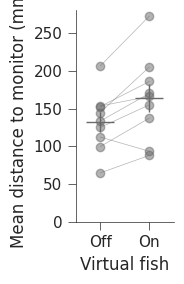

Wilcoxon signed-rank test statistic: 2.0
p-value: 0.01171875
average_off = 132.51 ± 18.766666666666666
average_on = 163.66 ± 13.163333333333334
delta_mean = 31.15 ± 7.88729764619456


,fish_id,average_on,average_off
0,0,140.146552,118.976808
1,1,48.206922,77.015039
2,2,123.157380,124.461856
3,3,176.875314,175.140295
4,4,55.744996,56.889134
5,5,43.391165,138.670524
6,6,138.616694,145.020509
7,7,227.986859,235.478747
8,8,127.003346,122.192333


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S8b


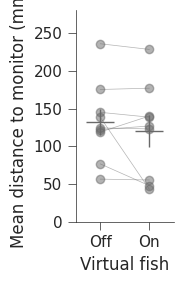

Wilcoxon signed-rank test statistic: 14.0
p-value: 0.359375
average_off = 132.65 ± 20.703333333333333
average_on = 120.13 ± 17.386666666666667
delta_mean = -12.52 ± 10.58234628411571


In [ ]:
subpanel = 'S8b'

OffTime = 300 #seconds
OnTime = 300 #seconds
on_vs_off =TimeBins[0:-1] % (OnTime+OffTime)

on_indices = np.where(on_vs_off > OnTime)[0]
off_indices = np.where(on_vs_off <= OnTime)[0]

for j in range(len(all_results)):
  ConditionArray = all_results[j]['distances']
  summary_list = []

  for i in range(ConditionArray.shape[0]):

    fish_data ={'fish_id':i,
                'average_on':np.nanmean(ConditionArray[i,on_indices]),
                'average_off':np.nanmean(ConditionArray[i,off_indices])}
    summary_list.append(fish_data)

  fish_df = pd.DataFrame(summary_list)
  display(fish_df)
  fish_df.to_csv(csv_path+subpanel+f"-{j}.csv",index=False)

  # Means for bars
  means = [fish_df['average_off'].mean(), fish_df['average_on'].mean()]
  sems = [fish_df['average_off'].sem(), fish_df['average_on'].sem()]

  fig, ax = plt.subplots(figsize=(2,3))

  # Plot mean + sem lines
  bar_positions = [0, 1]
  ax.errorbar(bar_positions, means, yerr=sems, fmt="_", markersize=20, markeredgewidth=1,\
          color='dimgrey', capsize=0, elinewidth=1)

  # Plot each fish's dots + connecting lines
  for _, row in fish_df.iterrows():
      ax.plot(
          bar_positions,
          [row['average_off'], row['average_on']],
          marker='o', color='dimgrey', alpha=0.5, lw=0.5
      )

  # Labels
  ax.set_xticks(bar_positions)
  ax.set_xticklabels(['Off', 'On'])
  ax.set_xlabel('Virtual fish')
  ax.set_ylabel('Mean distance to monitor (mm)')
  plt.xlim(-0.5,1.5)
  plt.ylim(0,280)
  plt.tight_layout(); sns.despine()
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f"-{j}.pdf",bbox_inches='tight')
  plt.show()

  ##Calulate p value using wilcoxon signed rank test (non-parametric paired test)
  from scipy.stats import wilcoxon

  # Perform the Wilcoxon signed-rank test
  statistic, p_value = wilcoxon(fish_df['average_off'], fish_df['average_on'])
  print(f"Wilcoxon signed-rank test statistic: {statistic}")
  print(f"p-value: {p_value}")

  average_on = np.round(fish_df['average_on'].mean(),2)
  average_off = np.round(fish_df['average_off'].mean(),2)
  sem_on = np.round(fish_df['average_on'].std(),2)/np.sqrt(fish_df.shape[0])
  sem_off = np.round(fish_df['average_off'].std(),2)/np.sqrt(fish_df.shape[0])
  delta_mean = np.round(average_on-average_off,2)
  sem_std = np.std(fish_df['average_on']-fish_df['average_off'])/np.sqrt(fish_df.shape[0])
  print(f"average_off = {average_off} ± {sem_on}")
  print(f"average_on = {average_on} ± {sem_off}")
  print(f"delta_mean = {delta_mean} ± {sem_std}")

# Data (fish do stuff)

In [55]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'fish_stim'

path = account_path + 'Yu_escape_paper/Imaging/Fish_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,trialNum
0,jy-260210-f1,t3-stimL_trim,1,4 4 4 3 4
1,jy-260210-f2,t3-stimR_trim,1,5 5 5 5 5
2,jy-260218-f1,t1-stimR_trim,1,5 6 5 6 7
3,jy-260218-f1,t2-stimR,1,10 10 10 10 10
4,jy-260218-f1,t3-stimR,1,10 10 10 10 10
5,jy-260218-f1,t4-stimR,1,10 10 10 10 10
6,jy-260218-f2,t1-stimL_trim,1,10 10 10 10 10
7,jy-260218-f2,t2-stimL,1,10 10 10 10 10
8,jy-260218-f2,t3-stimL,1,10 10 10 10 10
9,jy-260218-f2,t4-stimL,1,10 10 10 10 10


## stim type color scheme

In [56]:
# establish stim type num, names, and colors
resample_Hz = 10
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
event = 5*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

stim_names = ['BM-escape','BM-disappear','Linear-escape','Linear-disappear','BM-loom']
stim_colorz = ['darkorange','chocolate','teal','darkslategrey','maroon']

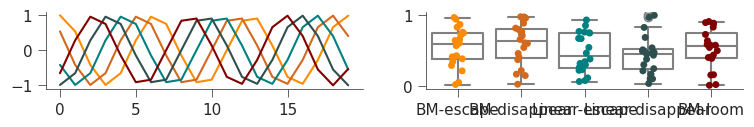

In [57]:
group_num = len(stim_names); group_names = stim_names
tmp = {n: np.random.random(20) for n in stim_names};

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=stim_colorz[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=stim_colorz); sns.despine();
plt.show()

# S8c - cell per plane

In [25]:
cell_per_session = {'per session':[], 'fish_ids':[]};
cell_per_plane = {'per plane':[]}

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # load processed data
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  traces_Z = data['traces_Z']

  # print("fish #", exp, ': ', ffile)
  cell_per_session['per session'].append(traces_Z.shape[0])
  [cell_per_plane['per plane'].append(traces_Z.shape[0]/plane_num) for i in range(plane_num)]
  cell_per_session['fish_ids'].append(exp)

for key, val in cell_per_session.items():
  cell_per_session[key] = np.array(val)
#
cell_per_fish = {'fish_ids':[], 'per fish':[]}
for fish in np.unique(cell_per_session['fish_ids']):
  cnt = np.sum(cell_per_session['per session']*[cell_per_session['fish_ids']==fish])
  cell_per_fish['per fish'].append(cnt)
  cell_per_fish['fish_ids'].append(fish)

cell_per_fish.pop('fish_ids')
print('done')

done



Each point is mean cell count from a plane
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8c


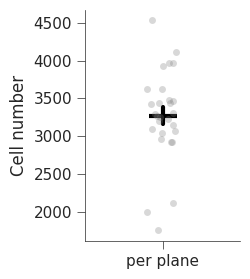

Ns, means, and  sems:
(N=28) 3269.429 ± 114.120


In [26]:
subpanel = 'S8c'

summary_data = cell_per_plane
# PLOT
print('\nEach point is mean cell count from a plane')
plt.figure(figsize=[2,3])
sns.stripplot(data=summary_data,color='gray',alpha=0.3,size=5)
sns.pointplot(data=summary_data,color='black',linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=3,errwidth=3);
plt.ylabel('Cell number');
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()
# STATS
print("Ns, means, and  sems:")
print(f"(N={len(summary_data['per plane'])}) {np.mean(summary_data['per plane']):.3f} ± {scipy.stats.sem(summary_data['per plane']):.3f}")

# save source data into csv
series_dict = {'per plane': cell_per_plane['per plane']}
df = pd.DataFrame(series_dict)
df.to_csv(csv_path+subpanel+'.csv')

# S8d - cell per brain region

In [27]:
# forebrain: forebrain, habenula
# midbrain: tectum_left, tectum_right, midbrain
# hindbrain: cerebellum, hindbrain

# count from each session

regions = ['forebrain','midbrain','hindbrain']
cell_by_region = {n: 0 for n in regions};
subregions = {'forebrain': ['forebrain','habenula'],'thalamus':['thalamus'],'tectum':['tectum_left','tectum_right'], 'hindbrain':['hindbrain','cerebellum']}
cell_by_subregion = {subreg_name: 0 for subreg_name,subreg in subregions.items()}

for exp, ffile, plane_num in zip(experiments, fcn_files, planeNum):
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # load cell xy positions
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  xs, ys, zs = data['xs'], data['ys'], data['zs']

  # load anatomy
  with open(load_path+'neuron_anatomy.pkl', 'rb') as f:
    cell_locations = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  for icell in range(len(cell_locations))[::]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region[reg]+=1
    # for subreg_name, subregs in subregions.items():
    #   for subreg in subregs:
    #     if subreg in cell_locations[icell]:
    #       # print(f"also part of {subreg_name}")
    #       cell_by_subregion[subreg_name]+=1
    for subreg_name, subregs in subregions.items():
      if any([reg in cell_locations[icell] for reg in subregs]):
        # print(f"also part of {subreg_name}")
        cell_by_subregion[subreg_name]+=1
  # break
print('done')

done


In [28]:
cell_by_subregion

{'forebrain': 14751, 'thalamus': 6864, 'tectum': 35092, 'hindbrain': 32699}

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8d


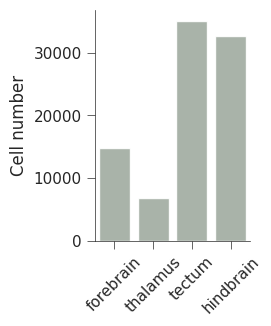

,forebrain,thalamus,tectum,hindbrain
0,14751,6864,35092,32699


In [29]:
subpanel = 'S8d'

summary_data = cell_by_subregion
# PLOT
plt.figure(figsize=[2,3])
sns.barplot(data=summary_data,color='darkseagreen',alpha=0.9,saturation=0.25)
plt.ylabel('Cell number'); plt.xticks(rotation=45); sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for key, val in cell_by_subregion.items():
  series_dict[key] = pd.Series(val)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv')

# S8e - summary response

In [30]:
!pip install upsetplot
from upsetplot import plot, UpSet; from matplotlib import pyplot
from upsetplot import from_contents, from_indicators, from_memberships, generate_counts

# Initialize containers for across-fish responsive cell analysis
across_fish_resp_ids = [[] for _ in range(len(stim_names))]
all_fish_cells = []  # to track all unique cell identifiers

print("Analyzing neural response overlap across all fish")
print("=" * 50)

for exp, ffile in zip(experiments[:], fcn_files[:]):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # (1) get cell response metrics
  data = np.load(output_path+'ttest_5-8.npz', allow_pickle=True)
  Pval = data['Pval']

  # categorize responsive or not
  all_profile = np.array([p<0.05 for p in Pval])

  # get cell ids with fish identifier
  cell_ids = np.arange(Pval.shape[1])

  # Create unique cell identifiers across fish: "fish_cellID"
  unique_cell_ids = [f"{exp}_{cell_id}" for cell_id in cell_ids]

  # Get responsive cell IDs for each stimulus (with fish identifier)
  resp_ids_this_fish = [
      [f"{exp}_{cell_id}" for cell_id in cell_ids[p<0.01]]
      for p in Pval
  ]

  # Append to across-fish responsive cell lists
  for stim_idx, resp_cells in enumerate(resp_ids_this_fish):
      across_fish_resp_ids[stim_idx].extend(resp_cells)

  # Print per-fish statistics
  print(f"  Responsive cells: {[len(cells) for cells in resp_ids_this_fish]}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24863 sha256=e720aa6febc112243934002b9d4e66fae925df5227227bc3d94472c5e70a483a
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot
Analyzing neural response overlap across all fish
  Responsive cells: [29, 37, 45, 34, 47]
  Responsive cells: [21, 17, 38, 33, 33]
  Responsive cells: [68, 80, 94, 76, 102]
  Responsive cells: [144, 130, 141, 163, 168]
  Responsive cells: [128, 143, 122, 122, 161]
  Responsive cells: [221, 207, 187, 192, 205]
  Responsive cells: [186, 204, 193, 170, 257]
  Responsive cells: [150, 150, 150, 157, 183]
  Responsive cells: [109, 145, 139, 127, 178]
  Responsive cells: [166, 162, 152, 164, 195]
  Responsive cells: [193, 180, 203, 170, 219]
  Responsive cells: [199, 176, 


Across-fish responsive cells n = [3680, 3617, 3659, 3554, 4197]

Deduplication check:
BM-escape: 3680 -> 3233 unique cells
BM-disappear: 3617 -> 3184 unique cells
Linear-escape: 3659 -> 3221 unique cells
Linear-disappear: 3554 -> 3132 unique cells
BM-loom: 4197 -> 3673 unique cells
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8e


/tmp/ipykernel_433/2909974782.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 400x300 with 0 Axes>

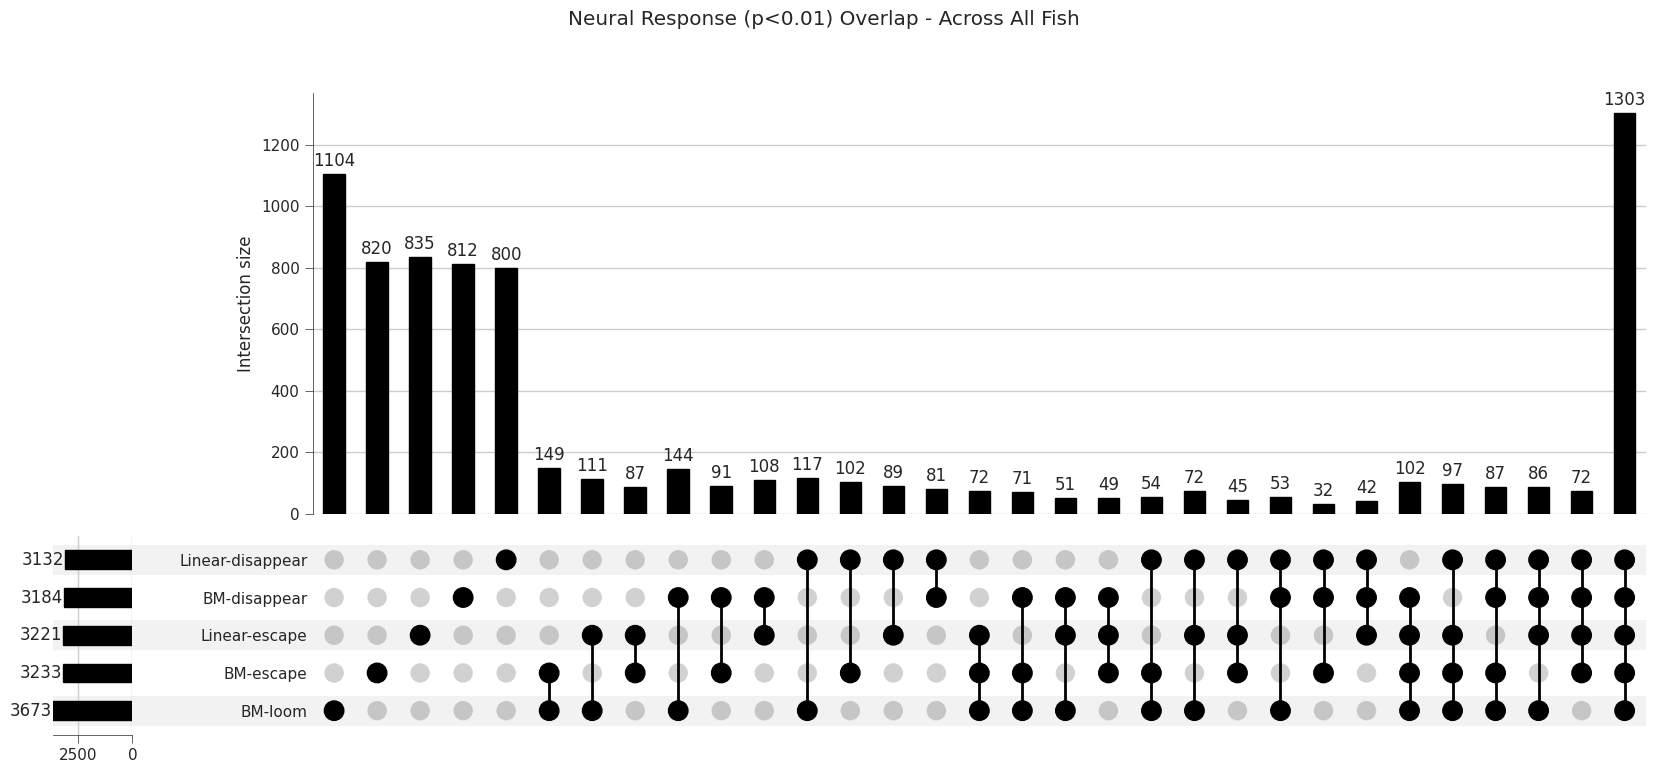


SUMMARY STATISTICS:
Total unique responsive cells across all fish: 7738
Total fish analyzed: 9
Average responsive cells per stimulus: 3741.4
Note: Could not save overlap statistics CSV file

Analysis complete!


In [31]:
subpanel = 'S8e'

print("\n" + "=" * 50)
print('Across-fish responsive cells n =', [len(cells) for cells in across_fish_resp_ids])

# Create UpSet plot for across-fish data - ensure unique cell lists per stimulus
across_fish_overlap_dict = {stim: list(set(cells)) for stim, cells in zip(stim_names, across_fish_resp_ids)}

# Debug: print lengths before and after deduplication
print("\nDeduplication check:")
for stim, cells in zip(stim_names, across_fish_resp_ids):
    unique_cells = list(set(cells))
    print(f"{stim}: {len(cells)} -> {len(unique_cells)} unique cells")

across_fish_overlap = from_contents(across_fish_overlap_dict)

# Create and save the plot
plt.figure(figsize=(4,3))
upset_plot = UpSet(across_fish_overlap, subset_size="count", show_counts=True,
                   element_size=40, intersection_plot_elements=10)
upset_plot.plot()
plt.suptitle('Neural Response (p<0.01) Overlap - Across All Fish', y=0.98)
plt.tight_layout()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# Print summary statistics
total_responsive_cells = len(np.unique(np.concatenate(across_fish_resp_ids)))
total_fish = len(set([exp for exp, _, _, _ in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:])]))

print(f"\nSUMMARY STATISTICS:")
print(f"Total unique responsive cells across all fish: {total_responsive_cells}")
print(f"Total fish analyzed: {total_fish}")
print(f"Average responsive cells per stimulus: {np.mean([len(cells) for cells in across_fish_resp_ids]):.1f}")

# Optional: Save the overlap statistics
try:
    overlap_stats = across_fish_overlap.to_frame().reset_index()
    overlap_stats.to_csv(csv_path + 'overlap_stats_across_fish.csv')
    print(f"Overlap statistics saved to: {csv_path}overlap_stats_across_fish.csv")
except:
    print("Note: Could not save overlap statistics CSV file")

print("\nAnalysis complete!")

# S8f - mean F

Each point is average of all cells in a session
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8f


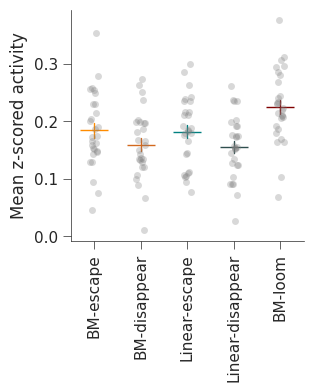

Ns, means, and  sems for data:
BM-escape: N=28 0.184 ± 0.012
BM-disappear: N=28 0.159 ± 0.011
Linear-escape: N=28 0.182 ± 0.011
Linear-disappear: N=28 0.156 ± 0.010
BM-loom: N=28 0.226 ± 0.012

Normality test (Shapiro-Wilk):
Group BM-escape: W = 0.979, p = 0.832
Group BM-disappear: W = 0.980, p = 0.844
Group Linear-escape: W = 0.964, p = 0.428
Group Linear-disappear: W = 0.984, p = 0.932
Group BM-loom: W = 0.975, p = 0.722
all groups are normally distributed → use parametric test.

One-way ANOVA:
             sum_sq     df         F    PR(>F)
group     0.087658    4.0  5.880917  0.000215
Residual  0.503060  135.0       NaN       NaN

Tukey's HSD post hoc test:
           Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
    BM-disappear        BM-escape   0.0253 0.5332 -0.0199 0.0704  False
    BM-disappear          BM-loom   0.0665

,BM-escape,BM-disappear,Linear-escape,Linear-disappear,BM-loom
0,0.045455,0.011027,0.095363,0.026282,0.068455
1,0.094565,0.099422,0.102961,0.127422,0.164666
2,0.186221,0.133280,0.184954,0.102663,0.168821
3,0.143873,0.134309,0.145490,0.072168,0.219396
4,0.158671,0.120340,0.104681,0.157362,0.209053
5,0.230703,0.250781,0.192271,0.156291,0.286384
6,0.229881,0.201681,0.239114,0.234889,0.281087
7,0.148841,0.158264,0.179364,0.174782,0.243908
8,0.130223,0.106161,0.109928,0.090952,0.163906
9,0.204698,0.199345,0.241603,0.175377,0.240645


In [32]:
subpanel = 'S8f'

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

# get basic metrics of neuron responses for each stim
MAX_F = {n: [] for n in stim_names}
MEAN_F = {n: [] for n in stim_names}
CELL_RATIO = {n: [] for n in stim_names}

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  cell_num = len(PSTHs)
  # load responsive cells
  data = np.load(output_path+'ttest_5-8_cells.npz',allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']

  # print(f"fish {exp}: {ffile}")
  # get metrics
  maxf = [[] for i in range(len(stim_names))]
  meanf = [[] for i in range(len(stim_names))]

  for i in range(len(stim_names)):
    for cell in cell_id[resp_arr[i]==True]:
      stim_psths = np.array(PSTHs[cell][i])
      maxf[i].append(np.nanmean(np.nanmax(stim_psths[:,pre:pre+stim_dur+off])))
      meanf[i].append(np.nanmean(np.nanmean(stim_psths[:,pre:pre+stim_dur+off])))

  # append to fish summary stats
  for i, stim in enumerate(stim_names):
    MAX_F[stim].append(np.mean(maxf[i]))
    MEAN_F[stim].append(np.mean(meanf[i]))
    CELL_RATIO[stim].append(len(cell_id[resp_arr[i]==True])/cell_num)
  # break


# PLOT
print('Each point is average of all cells in a session')

plt.figure(figsize=[3,3])
sns.stripplot(data=MEAN_F,color='gray',alpha=0.3,size=5)
sns.pointplot(data=MEAN_F,palette=stim_colorz,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Mean z-scored activity')
plt.xticks(range(len(stim_names)),stim_names,rotation=90)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# stats
group_values = MEAN_F
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f"{group_sizes[id]}: N={len(s)} {np.mean(s):.3f} ± {scipy.stats.sem(s):.3f}")

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups); annotation_dict = {}
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.5f}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.5f}")
  annotation_dict[(groups[0], groups[1])] = p

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]
        annotation_dict[(g1, g2)] = p

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)
      for g1, g2 in combinations(list(dunn.keys()), 2): annotation_dict[(g1, g2)] = dunn.loc[g1, g2]

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[key] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S8g - ratio

Each point is average of all cells in a session
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8g


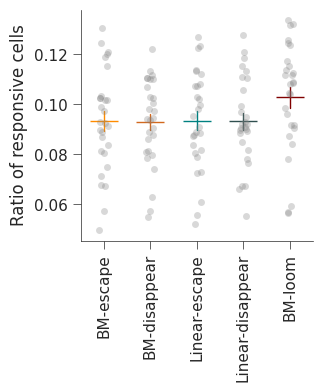

Ns, means, and  sems for data:
BM-escape: N=28 0.093 ± 0.004
BM-disappear: N=28 0.093 ± 0.003
Linear-escape: N=28 0.093 ± 0.004
Linear-disappear: N=28 0.093 ± 0.003
BM-loom: N=28 0.103 ± 0.004

Normality test (Shapiro-Wilk):
Group BM-escape: W = 0.980, p = 0.861
Group BM-disappear: W = 0.956, p = 0.277
Group Linear-escape: W = 0.974, p = 0.696
Group Linear-disappear: W = 0.973, p = 0.665
Group BM-loom: W = 0.932, p = 0.067
all groups are normally distributed → use parametric test.

One-way ANOVA:
             sum_sq     df         F    PR(>F)
group     0.002063    4.0  1.357138  0.252184
Residual  0.051292  135.0       NaN       NaN


,BM-escape,BM-disappear,Linear-escape,Linear-disappear,BM-loom
0,0.049713,0.057491,0.052080,0.055462,0.059182
1,0.057529,0.055028,0.061031,0.066033,0.056528
2,0.081312,0.081312,0.090878,0.081654,0.091561
3,0.101642,0.097304,0.107220,0.115277,0.113728
4,0.097322,0.111692,0.099935,0.089811,0.111692
5,0.120349,0.110465,0.112209,0.120930,0.112500
6,0.101911,0.102675,0.095287,0.097070,0.132229
7,0.102701,0.086152,0.087856,0.088586,0.117303
8,0.071492,0.079656,0.080538,0.076567,0.095984
9,0.089924,0.093955,0.083879,0.090428,0.108312


In [58]:
subpanel = 'S8g'

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

# get basic metrics of neuron responses for each stim
MAX_F = {n: [] for n in stim_names}
MEAN_F = {n: [] for n in stim_names}
CELL_RATIO = {n: [] for n in stim_names}

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  cell_num = len(PSTHs)
  # load responsive cells
  data = np.load(output_path+'ttest_5-8_cells.npz',allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']

  # print(f"fish {exp}: {ffile}")
  # get metrics
  maxf = [[] for i in range(len(stim_names))]
  meanf = [[] for i in range(len(stim_names))]

  for i in range(len(stim_names)):
    for cell in cell_id[resp_arr[i]==True]:
      stim_psths = np.array(PSTHs[cell][i])
      maxf[i].append(np.nanmean(np.nanmax(stim_psths[:,pre:pre+stim_dur+off])))
      meanf[i].append(np.nanmean(np.nanmean(stim_psths[:,pre:pre+stim_dur+off])))

  # append to fish summary stats
  for i, stim in enumerate(stim_names):
    MAX_F[stim].append(np.mean(maxf[i]))
    MEAN_F[stim].append(np.mean(meanf[i]))
    CELL_RATIO[stim].append(len(cell_id[resp_arr[i]==True])/cell_num)

# PLOT
print('Each point is average of all cells in a session')

plt.figure(figsize=[3,3])
sns.stripplot(data=CELL_RATIO,color='gray',alpha=0.3,size=5)
sns.pointplot(data=CELL_RATIO,palette=stim_colorz,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Ratio of responsive cells')
plt.xticks(range(len(stim_names)),stim_names,rotation=90)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# stats
group_values = CELL_RATIO
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()
print("Ns, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f"{group_sizes[id]}: N={len(s)} {np.mean(s):.3f} ± {scipy.stats.sem(s):.3f}")

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups); annotation_dict = {}
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.5f}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.5f}")
  annotation_dict[(groups[0], groups[1])] = p

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]
        annotation_dict[(g1, g2)] = p

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)
      for g1, g2 in combinations(list(dunn.keys()), 2): annotation_dict[(g1, g2)] = dunn.loc[g1, g2]

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[key] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S8h - SVM time series (BM-disp vs loom)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8h


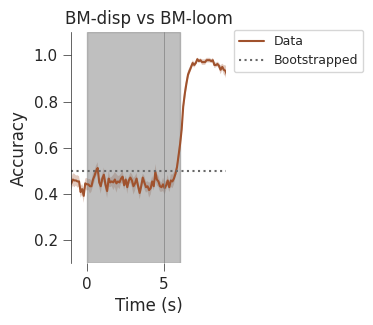

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.5625,0.4375,0.4375,0.4375,0.4375,0.5000,0.5625,0.5000,0.2500,0.5000,...,0.4850,0.4800,0.5100,0.4925,0.5050,0.4825,0.4875,0.5325,0.5050,0.4925
1,0.4375,0.4375,0.6250,0.3750,0.5000,0.5000,0.6875,0.4375,0.3125,0.5000,...,0.5200,0.5025,0.4825,0.4775,0.5150,0.5075,0.4725,0.4950,0.4700,0.4775
2,0.5625,0.3750,0.5000,0.4375,0.4375,0.5000,0.6250,0.3125,0.4375,0.5000,...,0.5125,0.4850,0.5100,0.4925,0.5075,0.5250,0.4900,0.5150,0.5100,0.5175
3,0.5625,0.4375,0.6250,0.5625,0.5000,0.4375,0.4375,0.5625,0.4375,0.5625,...,0.4950,0.4975,0.5175,0.5025,0.4975,0.4950,0.5375,0.5200,0.4825,0.4925
4,0.5000,0.5000,0.4375,0.5000,0.4375,0.4375,0.5000,0.4375,0.5000,0.4375,...,0.5025,0.4750,0.4950,0.4825,0.5025,0.5150,0.4800,0.4975,0.4950,0.4950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.6875,0.3750,0.6250,0.6875,0.7500,0.6875,0.5000,0.3750,0.3125,0.4375,...,0.4900,0.4875,0.4925,0.4975,0.5075,0.5075,0.4800,0.4775,0.4775,0.4925
246,0.6250,0.4375,0.6250,0.6250,0.7500,0.5000,0.5625,0.4375,0.3750,0.5625,...,0.4825,0.5250,0.4900,0.5050,0.4825,0.4950,0.4650,0.5250,0.4375,0.4850
247,0.6875,0.5000,0.5625,0.6250,0.7500,0.5000,0.5000,0.4375,0.2500,0.5000,...,0.5125,0.4850,0.5025,0.4725,0.5150,0.5000,0.5000,0.5025,0.4750,0.4925
248,0.6875,0.5625,0.5000,0.5625,0.6875,0.5000,0.2500,0.6250,0.2500,0.5000,...,0.4825,0.4775,0.5150,0.4825,0.5175,0.4875,0.4850,0.5150,0.5350,0.4850


In [34]:
subpanel = 'S8h'
decoder = 'svm_BM_disp_loom'; decoder_name = 'BM-disp vs BM-loom'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4,t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4,t5]])!=5: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

  # break

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axvline(5,color='gray',lw=0.5)
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel+f"")
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# S8i - tail moving during fish stim

In [35]:
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
Z_threshold = 2

# across fish summary
Z_per_stim = {n: [] for n in stim_names}
MOTION_per_stim = {n: [] for n in stim_names}

for exp, ffile, plane_num, trial_num in zip(experiments[::], fcn_files[::], planeNum[::], trialNum[::]):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)
  # load cell PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # load tail PSTHs
  with open(output_path+'tail_move_psths.pkl', 'rb') as f:
    tail_Z_PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # collect
  Z_fish = {n: [] for n in stim_names}; motion_fish = {n: [] for n in stim_names}
  for i, stim in enumerate(stim_names):
    for t in tail_Z_PSTHs[i]:
      Z_fish[stim].append(t)
      m = t > Z_threshold; motion_fish[stim].append(m)

  # append to across fish summary
  for n in stim_names:
    Z_per_stim[n].append(np.mean(Z_fish[n],axis=0))
    MOTION_per_stim[n].append(np.mean(motion_fish[n],axis=0))


Binned
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8i


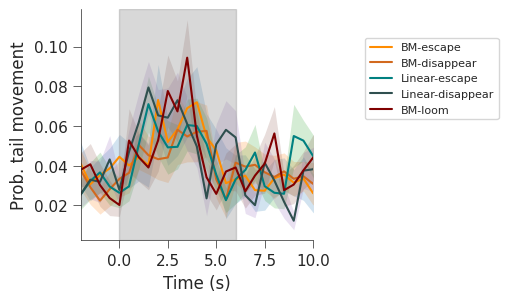

,BM-escape,BM-disappear,Linear-escape,Linear-disappear,BM-loom
0,0.033886,0.028036,0.020952,0.037837,0.030964
1,0.042109,0.025235,0.040493,0.046590,0.025998
2,0.045000,0.019323,0.053730,0.033560,0.027426
3,0.059643,0.051159,0.030646,0.031825,0.020238
4,0.053906,0.045442,0.039206,0.027528,0.030317
5,0.037151,0.036624,0.031871,0.024240,0.028724
6,0.041162,0.037925,0.025431,0.025507,0.037939
7,0.030692,0.029235,0.032347,0.032976,0.040743
8,0.035272,0.022421,0.036667,0.031916,0.030278
9,0.038676,0.028194,0.029541,0.043209,0.023739


In [36]:
subpanel = 'S8i'

# --- parameters ---
bin_length = 0.5 # seconds
bin_size = int(bin_length * resample_Hz)

# --- helpers ---
def bin_time_series(arr, bin_size):
    n_fish, T = arr.shape
    n_bins = T // bin_size
    arr = arr[:, :n_bins * bin_size]
    return arr.reshape(n_fish, n_bins, bin_size).mean(axis=2)
def mean_sem(arr):
    return arr.mean(axis=0), arr.std(axis=0) / np.sqrt(arr.shape[0])

# --- convert to arrays ---
Z_arr = {stim: np.array(Z_per_stim[stim]) for stim in stim_names}
M_arr = {stim: np.array(MOTION_per_stim[stim]) for stim in stim_names}

# --- bin data ---
Z_binned = {stim: bin_time_series(Z_arr[stim], bin_size) for stim in stim_names}
M_binned = {stim: bin_time_series(M_arr[stim], bin_size) for stim in stim_names}

# --- time axis ---
T = Z_arr[stim_names[0]].shape[1]
time = (np.arange(T) - pre) / resample_Hz
time_binned = time[:Z_binned[stim_names[0]].shape[1] * bin_size:bin_size]

print('Binned')
# --- plotting ---
plt.figure(figsize=[3,3])

for i, stim in enumerate(stim_names):
  mean_m, sem_m = mean_sem(M_binned[stim])
  plt.plot(time_binned, mean_m, label=stim, color=stim_colorz[i])
  plt.fill_between(time_binned, mean_m - sem_m, mean_m + sem_m, alpha=0.2,lw=0)

plt.xlim(-2,10)
plt.axvspan(0, stim_dur / resample_Hz, color='gray', alpha=0.3)
plt.axvline(10/0.5,color='gray',lw=0.5)
plt.xlabel('Time (s)'); plt.ylabel('Prob. tail movement')
sns.despine()
plt.legend(bbox_to_anchor=[1.2, 0.5], fontsize=8)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, stim in enumerate(stim_names):
  mean_m, sem_m = mean_sem(M_binned[stim])
  series_dict[stim] = pd.Series(mean_m)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S8j - motion modulation of response

In [37]:
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
Z_threshold = 2

# across fish summary
MOTION_per_stim = {n: [] for n in stim_names} # mean across trials
across_fish_summary = {f'{n}_move':[] for n in stim_names}
across_fish_summary.update({f'{n}_no_move':[] for n in stim_names})
trial_counts = {'move': 0, 'no_move': 0}

for exp, ffile, plane_num, trial_num in zip(experiments[::], fcn_files[::], planeNum[::], trialNum[::]):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)
  # load responsive cells
  data = np.load(output_path+'ttest_5-8_cells.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # load cell PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # load tail PSTHs
  with open(output_path+'tail_move_psths.pkl', 'rb') as f:
    tail_Z_PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # collect tail movements
  motion_fish = {n: [] for n in stim_names} # stim x trial
  for i, stim in enumerate(stim_names):
    # tail movement
    for t in tail_Z_PSTHs[i]: m = t > Z_threshold; motion_fish[stim].append(m)

  # categorize single psth into whether there's movement
  big_list = {f'{n}_move': [] for n in stim_names}
  big_list.update({f'{n}_no_move': [] for n in stim_names})

  start, end = pre, pre+stim_dur #+2*resample_Hz
  trial_cnt = {'move': 0, 'no_move': 0}
  for i, stim in enumerate(stim_names):
    for j, trial in enumerate(motion_fish[stim]):
      tmp = np.mean(trial[start:end])
      # motion_tmp[stim].append(tmp)
      if tmp>0:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list[f'{stim}_move'].append(np.mean(tr,axis=0))
        trial_cnt['move'] += 1
      else:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list[f'{stim}_no_move'].append(np.mean(tr,axis=0))
        trial_cnt['no_move'] += 1

  # append to across fish summary
  for n in stim_names:
    if len(big_list[f'{n}_move']) >0:
      across_fish_summary[f'{n}_move'].append(np.mean(big_list[f'{n}_move'],axis=0))
    if len(big_list[f'{n}_no_move']) > 0:
      across_fish_summary[f'{n}_no_move'].append(np.mean(big_list[f'{n}_no_move'],axis=0))
    trial_counts['move'] += trial_cnt['move']; trial_counts['no_move'] += trial_cnt['no_move']

print(trial_counts)

{'move': 3185, 'no_move': 2290}


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8j


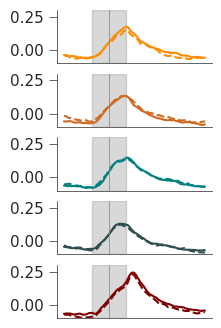

,BM-escape_move,BM-escape_no_move,BM-disappear_move,BM-disappear_no_move,Linear-escape_move,Linear-escape_no_move,Linear-disappear_move,Linear-disappear_no_move,BM-loom_move,BM-loom_no_move
0,-0.038489,-0.040064,-0.058315,-0.016977,-0.062774,-0.053824,-0.043606,-0.032807,-0.067566,-0.070770
1,-0.039872,-0.040310,-0.059442,-0.018527,-0.063242,-0.054273,-0.044486,-0.034735,-0.068255,-0.071929
2,-0.042061,-0.041275,-0.059946,-0.018787,-0.063384,-0.054083,-0.045197,-0.037023,-0.067416,-0.073951
3,-0.043503,-0.040808,-0.060454,-0.019378,-0.063945,-0.052650,-0.045261,-0.038830,-0.066689,-0.075708
4,-0.044197,-0.039677,-0.060529,-0.020729,-0.065120,-0.051112,-0.045420,-0.040358,-0.066153,-0.076398
...,...,...,...,...,...,...,...,...,...,...
245,-0.058845,-0.061484,-0.086909,-0.062443,-0.072142,-0.069573,-0.071247,-0.086629,-0.045297,-0.056549
246,-0.058852,-0.062179,-0.084930,-0.060797,-0.072319,-0.068693,-0.069337,-0.086356,-0.044042,-0.056029
247,-0.058826,-0.065047,-0.082807,-0.059584,-0.072213,-0.068437,-0.068474,-0.086654,-0.043540,-0.056080
248,-0.058623,-0.068405,-0.081352,-0.059293,-0.072017,-0.068893,-0.069197,-0.087744,-0.043618,-0.056616


In [38]:
subpanel = 'S8j'
# VISUALIZAE
plt.figure(figsize=[2,4])
# plt.subplot(121)
for i, stim in enumerate(stim_names):
  plt.subplot(5,1,i+1)
  m = np.mean(across_fish_summary[f'{stim}_move'],axis=0)
  plt.plot(m, color=stim_colorz[i], label=f'{stim}_move')
  nm = np.mean(across_fish_summary[f'{stim}_no_move'],axis=0)
  plt.plot(nm, color=stim_colorz[i], ls='--',label=f'{stim} w/o motion')
  plt.xticks([]); plt.ylim(-0.1,0.3)
  plt.axvline(pre+stim_dur/2,color='gray',lw=0.5)
  sns.despine(); plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}

for i, stim in enumerate(stim_names):
  m = np.mean(across_fish_summary[f'{stim}_move'],axis=0)
  nm = np.mean(across_fish_summary[f'{stim}_no_move'],axis=0)
  series_dict[f'{stim}_move'] = pd.Series(m)
  series_dict[f'{stim}_no_move'] = pd.Series(nm)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S8k - motion modulation of BM/LM escape cells

In [39]:
# look at general offset vs social offset cells (EDF8)
giant_list_bm = {f'{n}_move': [] for n in stim_names}
giant_list_bm.update({f'{n}_no_move': [] for n in stim_names})
giant_list_lm = {f'{n}_move': [] for n in stim_names}
giant_list_lm.update({f'{n}_no_move': [] for n in stim_names})
Z_threshold = 2

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # get cell respnse metrics
  data = np.load(output_path+'ttest_5-8_cells.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # filters for resp type
  swim_only = ((resp_arr[2,:])*(~resp_arr[3,:])); escp_only = ((~resp_arr[2,:])*(resp_arr[3,:]))
  both = ((resp_arr[2,:])*(resp_arr[3,:])); either = ((resp_arr[2,:])+(resp_arr[3,:]))
  # exclude loom only cells
  loom_only = ((~resp_arr[0,:])*(resp_arr[1,:])*(~resp_arr[2,:])*(~resp_arr[3,:]))
  exclude = (~loom_only)
  if np.sum(exclude) == 0: continue # skip if there's no such cells

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # load tail PSTHs
  with open(output_path+'tail_move_psths.pkl', 'rb') as f:
    tail_Z_PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # collect tail movements
  motion_fish = {n: [] for n in stim_names} # stim x trial
  for i, stim in enumerate(stim_names):
    # tail movement
    for t in tail_Z_PSTHs[i]: m = t > Z_threshold; motion_fish[stim].append(m)

  # compile responses
  big_list = {n: [] for n in stim_names}
  for cell in cell_id:
    for i, stim in enumerate(stim_names):
      p = np.mean(np.array(PSTHs[cell][i]),axis=0); big_list[f'{stim}'].append(p)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # categorize single psth into whether there's movement
  big_list_bm = {f'{n}_move': [] for n in stim_names}
  big_list_bm.update({f'{n}_no_move': [] for n in stim_names})
  big_list_lm = {f'{n}_move': [] for n in stim_names}
  big_list_lm.update({f'{n}_no_move': [] for n in stim_names})

  # get peaking time
  for i, stim in enumerate(stim_names):
    pk_tmp = np.argmax(big_list[f'{stim}'][:,:],axis=1); big_list[f'pk_{i+1}'] = pk_tmp

  # filter cell into social or general offset
  off_1 = (big_list['pk_1']>=100)*(big_list['pk_1']<=120)
  off_2 = (big_list['pk_2']>=100)*(big_list['pk_2']<=120)
  off_3 = (big_list['pk_3']>=100)*(big_list['pk_3']<=120)
  off_4 = (big_list['pk_4']>=100)*(big_list['pk_4']<=120)

  filter_bm = off_1*~off_3
  filter_lm = off_3*~off_1

  # TAIL MOTION calc
  start, end = pre, pre+stim_dur #+2*resample_Hz
  trial_cnt = {'move': 0, 'no_move': 0}
  for i, stim in enumerate(stim_names):
    for j, trial in enumerate(motion_fish[stim]):
      tmp = np.mean(trial[start:end])
      # motion_tmp[stim].append(tmp)
      if tmp>0:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list_bm[f'{stim}_move'].append(np.mean(tr[filter_bm],axis=0))
        big_list_lm[f'{stim}_move'].append(np.mean(tr[filter_lm],axis=0))
        trial_cnt['move'] += 1
      else:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list_bm[f'{stim}_no_move'].append(np.mean(tr[filter_bm],axis=0))
        big_list_lm[f'{stim}_no_move'].append(np.mean(tr[filter_lm],axis=0))
        trial_cnt['no_move'] += 1

  # append to across fish SUMMARY
  for i, stim in enumerate(stim_names):
    if len(big_list_bm[f'{stim}_move']) >0:
      giant_list_bm[f'{stim}_move'].append(np.mean(big_list_bm[f'{stim}_move'],axis=0))
    if len(big_list_bm[f'{stim}_no_move']) >0:
      giant_list_bm[f'{stim}_no_move'].append(np.mean(big_list_bm[f'{stim}_no_move'],axis=0))
    if len(big_list_lm[f'{stim}_move']) >0:
      giant_list_lm[f'{stim}_move'].append(np.mean(big_list_lm[f'{stim}_move'],axis=0))
    if len(big_list_lm[f'{stim}_no_move']) >0:
      giant_list_lm[f'{stim}_no_move'].append(np.mean(big_list_lm[f'{stim}_no_move'],axis=0))
    trial_counts['move'] += trial_cnt['move']; trial_counts['no_move'] += trial_cnt['no_move']

print(trial_counts)

  # break
for key, lst in giant_list_bm.items(): giant_list_bm[key] = np.array(lst)
for key, lst in giant_list_lm.items(): giant_list_lm[key] = np.array(lst)

{'move': 6370, 'no_move': 4580}


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8k-bm escp cells


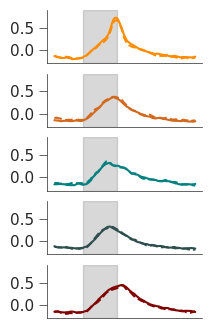

,BM-escape_move,BM-escape_no_move,BM-disappear_move,BM-disappear_no_move,Linear-escape_move,Linear-escape_no_move,Linear-disappear_move,Linear-disappear_no_move,BM-loom_move,BM-loom_no_move
0,-0.143559,-0.129896,-0.150735,-0.101413,-0.159438,-0.132994,-0.118054,-0.130311,-0.158612,-0.155444
1,-0.146342,-0.137926,-0.151225,-0.099259,-0.159068,-0.131700,-0.123773,-0.131221,-0.155998,-0.157311
2,-0.149036,-0.146416,-0.150363,-0.094690,-0.158290,-0.129119,-0.130200,-0.131740,-0.151998,-0.160897
3,-0.149985,-0.154282,-0.152117,-0.092494,-0.156837,-0.129530,-0.133296,-0.133766,-0.150850,-0.160797
4,-0.150621,-0.160365,-0.154661,-0.093005,-0.155996,-0.131152,-0.135030,-0.137314,-0.151919,-0.158712
...,...,...,...,...,...,...,...,...,...,...
245,-0.167219,-0.185156,-0.184673,-0.159949,-0.159437,-0.180115,-0.162894,-0.201185,-0.154346,-0.162449
246,-0.164587,-0.182553,-0.181075,-0.160723,-0.160344,-0.180173,-0.163350,-0.199450,-0.155640,-0.158705
247,-0.160439,-0.182686,-0.178086,-0.159400,-0.158776,-0.182717,-0.165118,-0.196042,-0.157798,-0.155924
248,-0.155448,-0.184988,-0.176781,-0.155802,-0.154237,-0.186116,-0.168525,-0.191519,-0.160419,-0.153552


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8k-lm escp


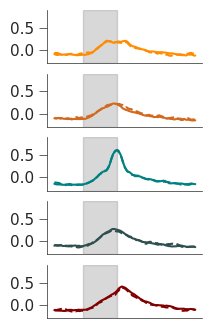

,BM-escape_move,BM-escape_no_move,BM-disappear_move,BM-disappear_no_move,Linear-escape_move,Linear-escape_no_move,Linear-disappear_move,Linear-disappear_no_move,BM-loom_move,BM-loom_no_move
0,-0.092814,-0.072442,-0.107738,-0.096739,-0.147991,-0.115265,-0.106844,-0.087646,-0.122475,-0.110850
1,-0.100687,-0.070634,-0.108915,-0.101301,-0.152445,-0.117336,-0.102030,-0.089911,-0.126584,-0.116025
2,-0.107001,-0.069771,-0.110593,-0.104331,-0.155362,-0.120350,-0.097892,-0.092273,-0.129865,-0.120964
3,-0.111721,-0.070877,-0.112328,-0.105475,-0.157458,-0.121300,-0.095840,-0.097583,-0.130704,-0.121983
4,-0.114901,-0.071993,-0.111463,-0.104288,-0.158393,-0.121516,-0.094892,-0.103654,-0.129918,-0.120902
...,...,...,...,...,...,...,...,...,...,...
245,-0.119292,-0.085044,-0.156897,-0.133334,-0.150269,-0.139514,-0.127669,-0.128879,-0.102083,-0.108878
246,-0.125386,-0.088794,-0.156009,-0.130385,-0.153604,-0.137721,-0.128374,-0.124610,-0.103972,-0.111378
247,-0.129389,-0.091584,-0.154558,-0.129032,-0.154601,-0.139460,-0.130620,-0.125368,-0.107321,-0.114873
248,-0.129595,-0.092585,-0.153547,-0.128585,-0.154192,-0.144004,-0.134642,-0.131574,-0.110127,-0.114838


In [40]:
subpanel = 'S8k'
# VISUALIZAE
plt.figure(figsize=[2,4])
# plt.subplot(121)
for i, stim in enumerate(stim_names):
  plt.subplot(5,1,i+1)
  m = np.mean(giant_list_bm[f'{stim}_move'],axis=0)
  plt.plot(m, color=stim_colorz[i], label=f'{stim}_move')
  nm = np.mean(giant_list_bm[f'{stim}_no_move'],axis=0)
  plt.plot(nm, color=stim_colorz[i], ls='--',label=f'{stim} w/o motion')
  plt.xticks([]); #plt.xlim(pre-2*resample_Hz,pre+stim_dur+4*resample_Hz)
  sns.despine(); plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  plt.ylim(-0.3,0.9)
print(figure_path+subpanel+'-bm escp cells')
plt.savefig(figure_path+subpanel+'-bm escp.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, stim in enumerate(stim_names):
  m = np.mean(giant_list_bm[f'{stim}_move'],axis=0)
  nm = np.mean(giant_list_bm[f'{stim}_no_move'],axis=0)
  series_dict[f'{stim}_move'] = pd.Series(m)
  series_dict[f'{stim}_no_move'] = pd.Series(nm)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'-bm escp.csv', index=False)

# VISUALIZAE
plt.figure(figsize=[2,4])
# plt.subplot(121)
for i, stim in enumerate(stim_names):
  plt.subplot(5,1,i+1)
  m = np.mean(giant_list_lm[f'{stim}_move'],axis=0)
  plt.plot(m, color=stim_colorz[i], label=f'{stim}_move')
  nm = np.mean(giant_list_lm[f'{stim}_no_move'],axis=0)
  plt.plot(nm, color=stim_colorz[i], ls='--',label=f'{stim} w/o motion')
  plt.xticks([]);
  sns.despine(); plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  plt.ylim(-0.3,0.9)
print(figure_path+subpanel+'-lm escp')
plt.savefig(figure_path+subpanel+'-lm escp.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, stim in enumerate(stim_names):
  m = np.mean(giant_list_lm[f'{stim}_move'],axis=0)
  nm = np.mean(giant_list_lm[f'{stim}_no_move'],axis=0)
  series_dict[f'{stim}_move'] = pd.Series(m)
  series_dict[f'{stim}_no_move'] = pd.Series(nm)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'-lm escp.csv', index=False)

# S8l-m BM/LM escape cells

In [59]:
regions = ['forebrain','midbrain','hindbrain']
subregions = {'forebrain': ['forebrain','habenula'],'thalamus':['thalamus'],\
              'tectum':['tectum_left','tectum_right'], 'hindbrain':['hindbrain','cerebellum']}

total_cell_by_region = {n: 0 for n in regions};
ratio_by_region_bm = {n: 0 for n in regions}
cell_by_region_bm = {n: 0 for n in regions};
cell_by_region_lm = {n: 0 for n in regions}

total_cell_by_subregion = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
ratio_by_subregion_lm = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
cell_by_subregion_bm = {subreg_name: 0 for subreg_name,subreg in subregions.items()}
cell_by_subregion_lm = {subreg_name: 0 for subreg_name,subreg in subregions.items()}

for exp, ffile, plane_num in zip(experiments, fcn_files, planeNum):
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # load anatomy
  with open(load_path+'neuron_anatomy.pkl', 'rb') as f:
    cell_locations = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # load cell selection
  data = np.load(output_path+'ttest_5-8_cells.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']

  # compile responses of all cells
  big_list = {'BM_escp':[],'BM_disp':[],'LM_escp':[],'LM_disp':[],'BM_loom':[]}

  for cell in cell_id:
    bm_escp = np.mean(np.array(PSTHs[cell][0]),axis=0); big_list['BM_escp'].append(bm_escp);
    bm_disp = np.mean(np.array(PSTHs[cell][1]),axis=0); big_list['BM_disp'].append(bm_disp);
    lm_escp = np.mean(np.array(PSTHs[cell][2]),axis=0); big_list['LM_escp'].append(lm_escp);
    lm_disp = np.mean(np.array(PSTHs[cell][3]),axis=0); big_list['LM_disp'].append(lm_disp);
    bm_loom = np.mean(np.array(PSTHs[cell][4]),axis=0); big_list['BM_loom'].append(bm_loom)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)
  # print(f'all responsive cell = {big_list[key].shape[0]}')

  # peaking time after stim onset
  start,end = 50, 130
  max_1 = np.max(big_list['BM_escp'][:,start:end],axis=1); big_list['max_1'] = np.array(max_1)
  pk_1 = np.argmax(big_list['BM_escp'][:,start:end],axis=1); big_list['pk_1'] = np.array(pk_1)
  max_2 = np.max(big_list['BM_disp'][:,start:end],axis=1); big_list['max_2'] = np.array(max_2)
  pk_2 = np.argmax(big_list['BM_disp'][:,start:end],axis=1); big_list['pk_2'] = np.array(pk_2)
  max_3 = np.max(big_list['LM_escp'][:,start:end],axis=1); big_list['max_3'] = np.array(max_3)
  pk_3 = np.argmax(big_list['LM_escp'][:,start:end],axis=1); big_list['pk_3'] = np.array(pk_3)
  max_4 = np.max(big_list['LM_disp'][:,start:end],axis=1); big_list['max_4'] = np.array(max_4)
  pk_4 = np.argmax(big_list['LM_disp'][:,start:end],axis=1); big_list['pk_4'] = np.array(pk_4)
  max_5 = np.max(big_list['BM_loom'][:,start:end],axis=1); big_list['max_5'] = np.array(max_5)
  pk_5 = np.argmax(big_list['BM_loom'][:,start:end],axis=1); big_list['pk_5'] = np.array(pk_5)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # find cells respond to escp/disp action
  off_1 = (big_list['pk_1']>=50)*(big_list['pk_1']<=70)
  off_2 = (big_list['pk_2']>=50)*(big_list['pk_2']<=70)
  off_3 = (big_list['pk_3']>=50)*(big_list['pk_3']<=70)
  off_4 = (big_list['pk_4']>=50)*(big_list['pk_4']<=70)

  # get total cell cnt
  # for icell in range(len(cell_locations))[::]:
  for icell in cell_id:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        total_cell_by_region[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          total_cell_by_subregion[subreg_name]+=1

  # filter the bm escp cells
  mask = off_1*~off_3
  for icell in np.arange(len(cell_locations))[cell_id][mask]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region_bm[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion_bm[subreg_name]+=1
  # filter the lm escp cells
  mask = off_3*~off_1
  for icell in np.arange(len(cell_locations))[cell_id][mask]:
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region_lm[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion_lm[subreg_name]+=1

  ratio_by_region_bm = {n: cell_by_region_bm[n]/total_cell_by_region[n]*100 for n in regions}
  ratio_by_subregion_bm = {n: cell_by_subregion_bm[n]/total_cell_by_subregion[n]*100 for n, _ in subregions.items()}

  ratio_by_region_lm = {n: cell_by_region_lm[n]/total_cell_by_region[n]*100 for n in regions}
  ratio_by_subregion_lm = {n: cell_by_subregion_lm[n]/total_cell_by_subregion[n]*100 for n, _ in subregions.items()}

## S8l - cell count by brain region

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8l


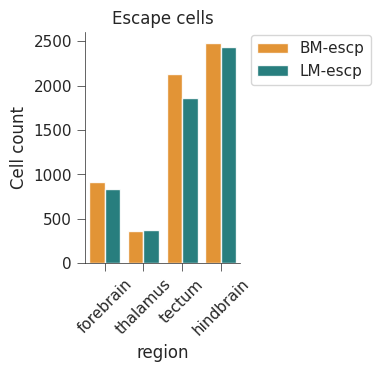

,region,count,cell_type
0,forebrain,919,BM-escp
1,thalamus,364,BM-escp
2,tectum,2130,BM-escp
3,hindbrain,2477,BM-escp
0,forebrain,833,LM-escp
1,thalamus,374,LM-escp
2,tectum,1865,LM-escp
3,hindbrain,2440,LM-escp


In [60]:
subpanel = 'S8l'
pal_color = ['darkorange','teal']

# cell counts
df1 = pd.DataFrame(list(cell_by_subregion_bm.items()), columns=["region", "count"]); df1['cell_type'] = 'BM-escp'
df2 = pd.DataFrame(list(cell_by_subregion_lm.items()), columns=["region", "count"]); df2['cell_type'] = 'LM-escp'
summary_data = pd.concat([df1,df2], ignore_index=False)

# PLOT
plt.figure(figsize=[2,3])
sns.barplot(data=summary_data,x='region',y='count',hue='cell_type',palette=pal_color,alpha=0.9)
plt.ylabel('Cell count'); plt.xticks(rotation=45); sns.despine(); plt.title('Escape cells')
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
display(summary_data)
df = pd.DataFrame(summary_data, columns=["region", "count","cell_type"]);
df.to_csv(csv_path+subpanel+'.csv')

## S8m - percentage by brain region

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8m


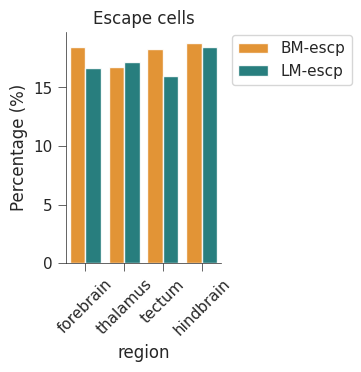

,region,percentage,cell_type
0,forebrain,18.413144,BM-escp
1,thalamus,16.704911,BM-escp
2,tectum,18.295825,BM-escp
3,hindbrain,18.767995,BM-escp
0,forebrain,16.690042,LM-escp
1,thalamus,17.163837,LM-escp
2,tectum,16.019584,LM-escp
3,hindbrain,18.487650,LM-escp


In [61]:
subpanel = 'S8m'
pal_color = ['darkorange','teal']

# cell counts
df1 = pd.DataFrame(list(ratio_by_subregion_bm.items()), columns=["region", "percentage"]); df1['cell_type'] = 'BM-escp'
df2 = pd.DataFrame(list(ratio_by_subregion_lm.items()), columns=["region", "percentage"]); df2['cell_type'] = 'LM-escp'
summary_data = pd.concat([df1,df2], ignore_index=False)

# PLOT
plt.figure(figsize=[2,3])
sns.barplot(data=summary_data,x='region',y='percentage',hue='cell_type',palette=pal_color,alpha=0.9)
plt.ylabel('Percentage (%)'); plt.xticks(rotation=45); sns.despine(); plt.title('Escape cells')
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
display(summary_data)
df = pd.DataFrame(summary_data, columns=["region", "percentage","cell_type"]);
df.to_csv(csv_path+subpanel+'.csv')

# Data: BG vs linear VR escape

In [44]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'BG_linear_escape'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition
0,vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T61,vid_1_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
1,vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T61,vid_8_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
2,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T61,vid_6_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
3,vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T61,vid_4_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
4,vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T61,vid_3_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,vid_14.mp4.000_vid_14.analysis.h5,vid_14.csv,U2,vid_14_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative
265,vid_13.mp4.000_vid_13.analysis.h5,vid_13.csv,U2,vid_13_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative
266,vid_12.mp4.000_vid_12.analysis.h5,vid_12.csv,U2,vid_12_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative
267,vid_11.mp4.000_vid_11.analysis.h5,vid_11.csv,U2,vid_11_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative


In [45]:
analysis_path = save_path

exps=metadata.index
#Create save directory for analysis
exp_dates = metadata['experiment_date'].tolist()
save_paths = [f'{analysis_path}{exp_date}/{exp}/lev0_basics.npz' for exp_date, exp in zip(exp_dates, exps)]
metadata['save_path'] = save_paths

#Add raw data path
data_paths = [f'{data_path}{exp_date}/{exp}/' for exp_date,exp in zip(exp_dates,exps)]
metadata['raw_data_path'] = data_paths

#Add timestamp path
TimeStamps=metadata['time_stamps'].tolist()
time_stamp_paths = [f'{data_path}/{exp_date}/{time}' for exp_date,time in zip(exp_dates,TimeStamps)]
metadata['time_stamp_path'] = time_stamp_paths

#Add bounding box path
boxes = [item for item in ['bounding_box_four_corners.csv'] for _ in range(len(metadata))]
box_dim_path=[f'{data_path}{exp_date}/{bbox}' for exp_date,bbox in zip(exp_dates,boxes)]
metadata['box_dim_path'] = box_dim_path

#Add metadata path for each video
metadatas = metadata['metadata'].tolist()
metadata_paths = [f'{data_path}{exp_date}/{meta}' for exp_date,meta in zip(exp_dates,metadatas)]
metadata['metadata_path'] = metadata_paths

#display(metadata)
display(metadata)

,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition,save_path,raw_data_path,time_stamp_path,box_dim_path,metadata_path
experiment,,,,,,,,,,,,,,,,,
vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T61,vid_1_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T61,vid_8_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T61,vid_6_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T61,vid_4_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T61,vid_3_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vid_14.mp4.000_vid_14.analysis.h5,vid_14.csv,U2,vid_14_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_13.mp4.000_vid_13.analysis.h5,vid_13.csv,U2,vid_13_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_12.mp4.000_vid_12.analysis.h5,vid_12.csv,U2,vid_12_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...


## helper fcn

In [51]:
import ast # Import the ast module
def get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order):
      #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)

    #Find transitions in showing fish (i.e. start and stop indexes)
    fs_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]])
    for x in range(0,len(fse_idx)):
      end_fs.append(EllapsedTime[fse_idx[x]])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)


    #Find transitions in fish escaping
    fe_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop,trial in zip(start_fe,end_fe,trial_order):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop,"NumFishEscape":trial})
    fe_df=pd.DataFrame(fe_results)


    return fs_df,fe_df

In [47]:
SE_colors = {'BG_negative':'#b7b7b7', 'BG_escape':'#df5106','BG_disappear':'#8A3324','BG_loom':'#d42222',
                'linear_negative':'#98b5ad','linear_escape':'#02b0b0','linear_disappear':'#036661'}

# S8n - speed to VR escape time series

There are 40 fish for BG_negative
There are 39 fish for BG_escape
There are 41 fish for BG_disappear
There are 42 fish for BG_loom
There are 35 fish for linear_negative
There are 36 fish for linear_escape
There are 34 fish for linear_disappear
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8n


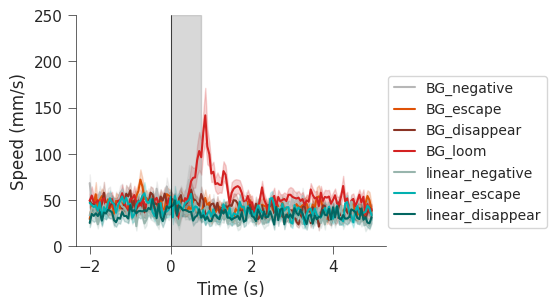

,BG_negative_1,BG_negative_2,BG_negative_3,BG_negative_4,BG_negative_5,BG_negative_6,BG_negative_7,BG_negative_8,BG_negative_9,BG_negative_10,...,linear_disappear_25,linear_disappear_26,linear_disappear_27,linear_disappear_28,linear_disappear_29,linear_disappear_30,linear_disappear_31,linear_disappear_32,linear_disappear_33,linear_disappear_34
0,125.892756,NaN,NaN,87.955905,NaN,85.440695,90.709057,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,111.717397,4.182751,35.537243,77.790216,85.233972,111.145016,76.447177,81.595476,113.198766,61.867392,...,2.389225,2.046419,29.081556,3.418382,26.270380,62.247010,4.597172,3.093842,19.540260,1.987805
2,80.428561,14.963056,56.476850,52.849303,85.722462,141.584147,72.555651,78.640838,54.205547,35.965898,...,1.162253,1.455619,25.800001,5.778011,75.383819,9.709205,2.101585,19.461582,59.927273,5.742491
3,75.424332,19.227748,43.200497,4.007214,17.673811,73.748523,102.339456,116.810195,9.144092,87.009128,...,1.758389,3.552357,25.789016,0.462356,2.580268,94.489982,3.562865,8.936754,93.976811,4.562071
4,39.791925,65.099681,8.750461,49.810950,35.768454,11.082595,101.914078,58.487033,16.204152,84.855270,...,0.618702,13.953573,34.772933,5.722356,6.302644,7.416723,2.425124,2.392355,56.192109,1.742111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,4.262845,9.741369,49.417508,78.994720,98.709744,48.785732,95.418518,2.579687,71.545142,5.475015,...,0.934017,50.150332,4.335752,3.335329,37.885156,60.413137,3.827202,0.859094,61.706062,2.765590
136,3.002884,69.920765,76.390000,7.415974,2.359742,9.403331,33.752125,8.889739,64.524982,93.568214,...,4.155219,5.894930,1.846865,2.870033,215.702962,26.565480,1.463571,1.924617,53.287955,4.296342
137,21.791168,4.367529,115.408273,71.266717,6.949632,76.062653,73.683336,3.425433,40.726494,20.016416,...,65.742880,3.167654,2.249304,5.613970,89.186877,40.041245,53.287525,1.400634,61.289940,1.064360
138,21.657539,51.755037,101.905571,2.196055,2.012446,91.908717,49.375274,3.523278,9.385981,18.419802,...,18.205665,79.546613,1.839603,21.433515,54.691858,16.531968,4.523845,0.417721,29.508701,1.474469


In [52]:
subpanel = 'S8n'

from scipy.interpolate import interp1d
## Velocity relative to stim start
TimeBufferAfter = 5
TimeBufferBefore = 2
FishEscapeTime = 0
Times = []
Fish_escapees=[1]
escape_data=[]
pseudo_trigger_data=[]
distances = []
metadata_subset = metadata #[metadata['tank'] != 'T26'].reset_index()
stim_types = ['BG_negative','BG_escape','BG_disappear','BG_loom','linear_negative','linear_escape','linear_disappear', ]

# initiate to save source data later
series_dict = {}
for stim in stim_types:
  metadata_subset = metadata[metadata['condition'] == stim].reset_index()
  counter = 0
  for i in range(len(metadata_subset.index)):

      data_path = metadata_subset['save_path'].iloc[i]
      data = np.load(data_path, allow_pickle=True)
      fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
      exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
      EllapsedTime = data['time_stamps']
      condition = data['condition']
      ArenaDims = get_arena_dims(data)
      trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
      EngageThresh=float(data['vid_metadata'].item()['Engagement distance threshold'])

      # Calculate scale
      #arenaHeightPix=np.sqrt( (TopLeftX-BottomLeftX )**2 + (TopLeftY-BottomLeftY)**2)
      scale=metadata_subset['rig_mm'].iloc[i]/ArenaDims['BBW'].values[0]

      # Get stim status and escape time stamps
      fish_escaping = data['fish_escaping']
      if sum(fish_escaping) == 0:
        continue

      counter+=1
      fish_showing = data['fish_showing']
      fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)
      for escape_event in range(len(fe)):
          start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
          end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
          trigger_time = fe['StartFishEscaping'].iloc[escape_event]

          start_idx = np.nanargmin(np.abs(EllapsedTime-start_time))#, side="left")
          end_idx = np.nanargmin(np.abs(EllapsedTime-end_time))#, side="right")
          trigger_idx = np.nanargmin(np.abs(EllapsedTime-trigger_time))

          pos_at_trigger = np.array([f_x[0][trigger_idx],f_y[0][trigger_idx]])
          pos_at_trigger = pos_at_trigger[:, None]

          pos_during_window =np.array([f_x[0][start_idx:end_idx],f_y[0][start_idx:end_idx]])
          ET = np.array(([EllapsedTime[start_idx:end_idx]-EllapsedTime[trigger_idx]]))
          dt = np.diff(ET)
          dt[dt==0] = np.nan
          dpos = np.diff(pos_during_window, axis=1)
          velocity = np.linalg.norm(dpos, axis=0) / dt

          #trigger_index =
          escape_data.append({
              "NumEscapees": fe["NumFishEscape"].iloc[escape_event],
              "Times": ET[0][0:-1],
              "Distances": velocity[0] * scale,
              "fish":i,
              "Condition":stim})

  print(f'There are {counter} fish for {stim}')

# Plot average
histbin = 0.05
TotalTime = TimeBufferBefore + TimeBufferAfter
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-histbin, int(TotalTime / histbin))
num_escapees = [5]

binned_data = []
for stim in stim_types:
    escape_events = [event for event in escape_data if event["Condition"] == stim]
    Times = [event["Times"] for event in escape_events]
    distances = [event["Distances"] for event in escape_events]
    conditions = [event["Condition"] for event in escape_events]

    # Get time bin indices
    bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]

    # Create distance array
    DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)

    # save
    for j in range(DistanceArray.shape[1]):
      col_name = f'{stim}_{j+1}'
      series_dict[col_name] = pd.Series(DistanceArray[:,j])

    for fish_idx in range(len(distances)):
        t = Times[fish_idx]
        d = distances[fish_idx]
        if len(t) > 1:
            # Create an interpolation function for this specific fish
            f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
            DistanceArray[:, fish_idx] = f(TimeBins)

    DistanceMean=np.nanmean(DistanceArray,axis=1)
    DistanceSEM=(np.nanstd(DistanceArray,axis=1)/np.sqrt(len(distances)))
    plt.plot(TimeBins, DistanceMean,label=stim,color=SE_colors[stim])
    plt.fill_between(TimeBins, (DistanceMean- DistanceSEM), (DistanceMean+ DistanceSEM), alpha=0.2,color=SE_colors[stim])

    binned_data.append({'Time': TimeBins,
                        'Condition': [stim] * len(DistanceArray),
                        'Velocity': DistanceArray})

    plt.ylabel('Speed (mm/s)')
    plt.xlabel('Time (s)')
    plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
    ax = plt.gca()  # Get current axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.ylim(0,250)

plt.axvspan(0,0.75,color='grey',alpha=0.3)
plt.axvline(x=0, color='black',lw=0.5)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S8o - speed to VR stats

/tmp/ipykernel_433/4262612844.py:19: RuntimeWarning: All-NaN slice encountered
  median_distances = np.nanmedian(np.vstack(distances),axis=0)
/tmp/ipykernel_433/4262612844.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S8o


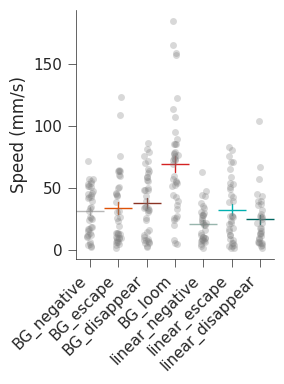

Ns, means, and  sems for data:
BG_negative: (N=39) 31.081, 3.058
BG_escape: (N=39) 33.483, 4.712
BG_disappear: (N=41) 37.731, 3.959
BG_loom: (N=42) 69.439, 6.607
linear_negative: (N=35) 21.109, 2.469
linear_escape: (N=36) 32.294, 4.217
linear_disappear: (N=34) 24.494, 3.676
--- Omnibus Test Results ---
Kruskal-Wallis H-statistic: 46.3810
p-value: 2.4859727512e-08

Significant difference found! Running Dunn's post-hoc test...

--- Dunn's Post-Hoc p-values Matrix ---
                  BG_negative  BG_escape  BG_disappear       BG_loom  \
BG_negative          1.000000   1.000000      1.000000  5.164375e-04   
BG_escape            1.000000   1.000000      1.000000  3.026296e-04   
BG_disappear         1.000000   1.000000      1.000000  1.413273e-02   
BG_loom              0.000516   0.000303      0.014133  1.000000e+00   
linear_negative      1.000000   1.000000      0.122983  1.043603e-07   
linear_escape        1.000000   1.000000      1.000000  3.722469e-04   
linear_disappear     1.000

,BG_negative,BG_escape,BG_disappear,BG_loom,linear_negative,linear_escape,linear_disappear
0,25.527607,9.496080,8.166751,54.083098,12.165958,70.629991,17.541452
1,57.112962,26.396773,64.987278,72.048708,16.178641,50.556631,28.751394
2,18.660985,10.166126,6.930239,77.054803,7.813065,54.097505,37.033442
3,16.768776,50.684522,33.965911,5.043766,8.048720,1.441220,2.850086
4,13.067218,75.930722,55.692991,25.456176,10.339185,2.931678,24.500513
5,47.434056,13.522100,6.484512,85.143152,21.862137,27.212910,31.638056
6,6.339138,109.002291,69.840443,75.582584,1.212259,15.307216,8.477610
7,50.647576,63.771287,47.837517,76.446119,37.988759,1.695596,13.592798
8,51.752979,23.106254,49.951370,55.806082,9.063645,58.946162,6.276411
9,14.753602,63.523456,62.168442,157.425172,4.828939,39.165095,39.483006


In [53]:
subpanel = 'S8o'

## Create an SEM plot and do stats ##
StartTime = 0.5
EndTime = 1.5 #seconds after stimulus onset
bin_df = pd.DataFrame(binned_data)
bin_df = bin_df.explode(['Time', 'Velocity',  'Condition'])
bin_df = bin_df.reset_index(drop=True)
plot_df = pd.DataFrame(columns=['Time', 'Velocity', 'Condition'])

dfs = []
for stim in stim_types:
    bin_df_subset = bin_df[bin_df['Condition'] == stim]
    idx_start = np.searchsorted(bin_df_subset['Time'], StartTime)
    idx_end = np.searchsorted(bin_df_subset['Time'], EndTime)
    if idx_end <= idx_start:
        continue
    distances = np.stack(bin_df_subset['Velocity'].iloc[idx_start:idx_end])
    median_distances = np.nanmedian(np.vstack(distances),axis=0)

    mini_df = pd.DataFrame({
        'Velocity': median_distances,
        'Condition': [bin_df_subset['Condition'].iloc[0]] * len(median_distances),
        'Fish_ID': np.arange(0,len(median_distances))
    })

    dfs.append(mini_df)

plot_df = pd.concat(dfs, ignore_index=True)
condition_order = stim_types # Desired order

plt.figure(figsize=(3, 4))
ax = plt.gca()
ax.set_ylabel("Speed (mm/s)")

sns.stripplot(data=plot_df, x="Condition", y="Velocity", order=condition_order,\
              color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
sns.pointplot(data=plot_df, x="Condition", y="Velocity", order=condition_order,\
              palette=SE_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);

ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Remove top box line and right box line
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

group_arrays = [plot_df[plot_df['Condition'] == cond]['Velocity'].values for cond in condition_order]
# Remove nans from group_arrays
group_arrays = [arr[~np.isnan(arr)] for arr in group_arrays]

# stats
print("Ns, means, and  sems for data:")
for cond, data in zip(condition_order,group_arrays):
  print(f'{cond}: (N={len(data)}) {np.nanmean(data):.3f}, {scipy.stats.sem(data):.3f}')

# Run Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(*group_arrays)
print("--- Omnibus Test Results ---")
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.10e}")

# 2. Post-hoc Dunn's test (If Significant)
if p_val < 0.05:
    print("\nSignificant difference found! Running Dunn's post-hoc test...")

    # Run Dunn's test with Holm-Bonferroni correction
    dunn_matrix = scikit.posthoc_dunn(
        plot_df,
        val_col='Velocity',
        group_col='Condition',
        p_adjust='Holm')

    # Filter and reorder the giant matrix to match your list order perfectly
    ordered_dunn = dunn_matrix.loc[condition_order, condition_order]

    print("\n--- Dunn's Post-Hoc p-values Matrix ---")
    # Display the styled matrix or just print it
    print(ordered_dunn)
else:
    print("\nNo significant differences found across conditions.")

# save source data into csv
series_dict = {}
for key, values in zip(condition_order,group_arrays):
  series_dict[f'{key}'] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)